# 🧠 FST Béni Mellal — USMS
## Master AIDC — Deep Learning | Année Universitaire 2025–2026

---

# Exercice 2 — Image Captioning
## Architecture CNN-LSTM avec Mécanisme d'Attention Visuelle

**Auteur :** *(votre nom)*  
**Date :** *(date)*  
**Environnement :** Google Colab / Kaggle (GPU T4/P100)

---

### Objectifs
- Construire un pipeline complet d'Image Captioning (CNN + LSTM)
- Implémenter un mécanisme d'attention visuelle (Bahdanau)
- Évaluer avec les métriques BLEU, METEOR, CIDEr
- Visualiser les cartes d'attention générées

## ⚙️ Installation des dépendances

In [ ]:
# Installation des packages nécessaires
!pip install pycocotools nltk opencv-python-headless -q
!pip install torch torchvision -q  # déjà installé sur Colab/Kaggle

# Téléchargement des ressources NLTK pour BLEU
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print('✅ Dépendances installées')

✅ Dépendances installées


## 📦 Imports globaux

In [ ]:
import os
import re
import json
import time
import math
import random
import numpy as np
from collections import Counter
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import cv2

from pycocotools.coco import COCO
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction

# Reproductibilité
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'🖥️  Device utilisé : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'   GPU : {torch.cuda.get_device_name(0)}')
    print(f'   VRAM disponible : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

🖥️  Device utilisé : cuda
   GPU : Tesla T4
   VRAM disponible : 15.6 GB


## 📥 Téléchargement du dataset MS-COCO 2017 (subset)

> **Note Kaggle :** Si vous utilisez le dataset depuis Kaggle, adaptez `DATA_ROOT` ci-dessous.  
> Le script suivant télécharge un sous-ensemble de 5 000 images train + 500 val.

In [ ]:
# ─────────────────────────────────────────────────────────────
# CONFIGURATION — Adaptez ces chemins à votre environnement
# ─────────────────────────────────────────────────────────────
DATA_ROOT   = './coco_subset'   # dossier racine du dataset
TRAIN_DIR   = os.path.join(DATA_ROOT, 'train2017')
VAL_DIR     = os.path.join(DATA_ROOT, 'val2017')
ANN_DIR     = os.path.join(DATA_ROOT, 'annotations')
TRAIN_ANN   = os.path.join(ANN_DIR, 'captions_train2017.json')
VAL_ANN     = os.path.join(ANN_DIR, 'captions_val2017.json')
CKPT_DIR    = './checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)

# ─────────────────────────────────────────────────────────────
# Téléchargement COCO (exécutez uniquement si les fichiers
# ne sont pas encore présents)
# ─────────────────────────────────────────────────────────────
if not os.path.exists(TRAIN_ANN):
    print('⬇️  Téléchargement des annotations COCO...')
    os.makedirs(ANN_DIR, exist_ok=True)
    !wget -q http://images.cocodataset.org/annotations/annotations_trainval2017.zip -O /tmp/ann.zip
    !unzip -q /tmp/ann.zip -d {DATA_ROOT}
    print('   ✅ Annotations extraites')
else:
    print('✅ Annotations déjà présentes')

# Sous-ensemble d'images — on utilise les annotations existantes
# et on télécharge uniquement les images référencées
def download_coco_subset(ann_file, img_dir, max_images=5000, split='train'):
    """Télécharge un sous-ensemble d'images COCO."""
    os.makedirs(img_dir, exist_ok=True)
    with open(ann_file) as f:
        data = json.load(f)

    # Sélectionner max_images images uniques
    image_ids = list({ann['image_id'] for ann in data['annotations']})[:max_images]
    img_info  = {img['id']: img for img in data['images']}

    base_url = f'http://images.cocodataset.org/{split}2017/'
    downloaded = 0
    for img_id in image_ids:
        fname = img_info[img_id]['file_name']
        fpath = os.path.join(img_dir, fname)
        if not os.path.exists(fpath):
            os.system(f'wget -q {base_url}{fname} -O {fpath}')
            downloaded += 1
    print(f'   ✅ {downloaded} nouvelles images téléchargées ({split})')
    return image_ids

# Décommentez si vous souhaitez télécharger les images automatiquement
# (peut prendre plusieurs minutes)
# download_coco_subset(TRAIN_ANN, TRAIN_DIR, max_images=5000, split='train')
# download_coco_subset(VAL_ANN,   VAL_DIR,   max_images=500,  split='val')

print(f'\n📂 Structure attendue :')
print(f'   {DATA_ROOT}/')
print(f'   ├── train2017/   (5 000 images .jpg)')
print(f'   ├── val2017/     (500 images .jpg)')
print(f'   └── annotations/')
print(f'       ├── captions_train2017.json')
print(f'       └── captions_val2017.json')

⬇️  Téléchargement des annotations COCO...
   ✅ Annotations extraites

📂 Structure attendue :
   ./coco_subset/
   ├── train2017/   (5 000 images .jpg)
   ├── val2017/     (500 images .jpg)
   └── annotations/
       ├── captions_train2017.json
       └── captions_val2017.json


---
# Partie 1 — Préparation du Dataset COCO et Vocabulaire

### Classe Vocabulary (fournie par le TP)

In [ ]:
class Vocabulary:
    """Gestion du vocabulaire : tokens spéciaux + mots fréquents."""

    def __init__(self, freq_threshold=5):
        self.freq_threshold = freq_threshold
        # Tokens spéciaux : PAD=0, SOS=1, EOS=2, UNK=3
        self.itos = {0: '<PAD>', 1: '<SOS>', 2: '<EOS>', 3: '<UNK>'}
        self.stoi = {v: k for k, v in self.itos.items()}

    def __len__(self):
        return len(self.itos)

    @staticmethod
    def tokenize(text):
        """Tokenisation simple par mots alphanumériques en minuscules."""
        return re.findall(r'\w+', text.lower())

    def build(self, captions_list):
        """Construit le vocabulaire depuis une liste de listes de captions."""
        counter = Counter()
        for caps in captions_list:
            for cap in caps:
                counter.update(self.tokenize(cap))
        idx = 4
        for word, freq in counter.items():
            if freq >= self.freq_threshold:
                self.stoi[word] = idx
                self.itos[idx]  = word
                idx += 1
        print(f'📚 Taille du vocabulaire : {len(self.itos)} tokens')

    def numericalize(self, caption, max_len=50):
        """Convertit une caption en séquence d'indices paddée."""
        tokens = [self.stoi.get(w, self.stoi['<UNK>'])
                  for w in self.tokenize(caption)]
        seq = [self.stoi['<SOS>']] + tokens[:max_len - 2] + [self.stoi['<EOS>']]
        seq += [self.stoi['<PAD>']] * (max_len - len(seq))
        return seq

    def decode(self, indices):
        """Convertit une liste d'indices en phrase lisible."""
        words = []
        for idx in indices:
            w = self.itos.get(int(idx), '<UNK>')
            if w in ('<EOS>', '<PAD>'):
                break
            if w not in ('<SOS>', '<PAD>'):
                words.append(w)
        return ' '.join(words)

---
### ❓ Q1 — Construction du vocabulaire & analyse des captions

**Consigne :** Construire le vocabulaire avec `freq_threshold=5`. Afficher :
- La taille du vocabulaire
- Les 20 mots les plus fréquents
- La distribution des longueurs de captions (histogramme)
- Justification du choix de `max_len`

📚 Taille du vocabulaire : 2374 tokens


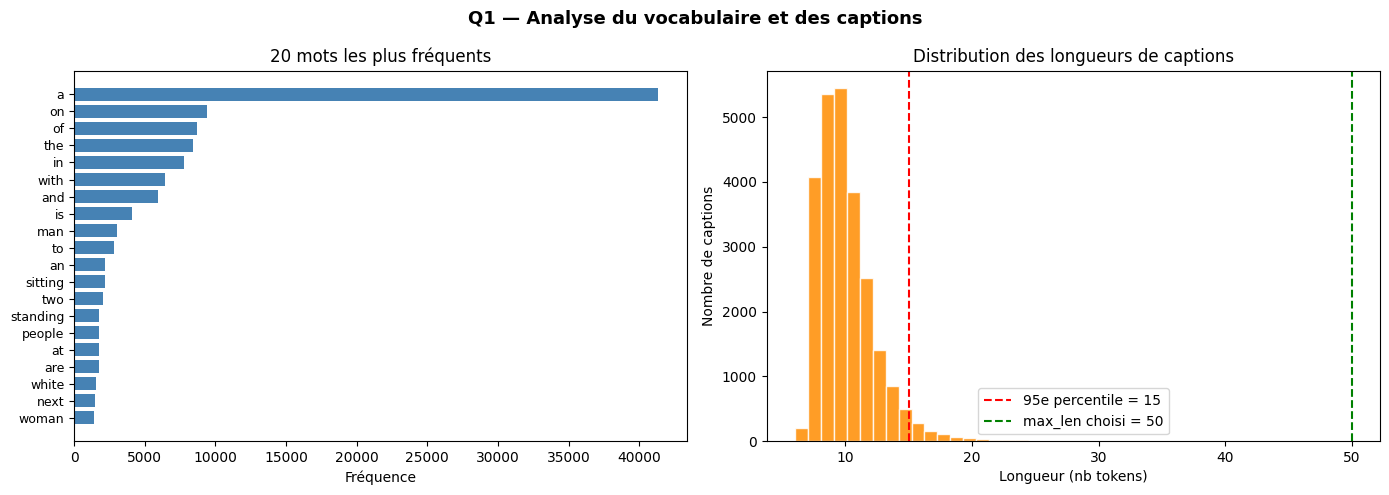


📊 Statistiques des longueurs :
   Moyenne  : 10.5 tokens
   Médiane  : 10.0 tokens
   Max      : 47 tokens
   95e pct  : 15 tokens
   Couverture avec max_len=50 : 100.0% des captions


In [ ]:
# ── Chargement des annotations ──────────────────────────────────────────────
with open(TRAIN_ANN) as f:
    train_data = json.load(f)

# Limiter au sous-ensemble de 5 000 images
all_image_ids = list({ann['image_id'] for ann in train_data['annotations']})
SUBSET_IDS    = set(all_image_ids[:5000])

# Regrouper les captions par image
img_to_caps = {}
for ann in train_data['annotations']:
    if ann['image_id'] in SUBSET_IDS:
        img_to_caps.setdefault(ann['image_id'], []).append(ann['caption'])

# Construction du vocabulaire
MAX_LEN = 50
vocab   = Vocabulary(freq_threshold=5)
vocab.build(list(img_to_caps.values()))

# ── Analyse : 20 mots les plus fréquents ────────────────────────────────────
all_captions = [cap for caps in img_to_caps.values() for cap in caps]
word_counter  = Counter()
for cap in all_captions:
    word_counter.update(Vocabulary.tokenize(cap))

top20 = word_counter.most_common(20)
words_top20, freqs_top20 = zip(*top20)

# ── Distribution des longueurs ───────────────────────────────────────────────
lengths = [len(Vocabulary.tokenize(cap)) for cap in all_captions]
p95 = np.percentile(lengths, 95)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphe 1 : top 20 mots
axes[0].barh(list(reversed(words_top20)), list(reversed(freqs_top20)), color='steelblue')
axes[0].set_xlabel('Fréquence')
axes[0].set_title('20 mots les plus fréquents')
axes[0].tick_params(axis='y', labelsize=9)

# Graphe 2 : distribution des longueurs
axes[1].hist(lengths, bins=40, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].axvline(p95, color='red', linestyle='--', linewidth=1.5,
                label=f'95e percentile = {p95:.0f}')
axes[1].axvline(MAX_LEN, color='green', linestyle='--', linewidth=1.5,
                label=f'max_len choisi = {MAX_LEN}')
axes[1].set_xlabel('Longueur (nb tokens)')
axes[1].set_ylabel('Nombre de captions')
axes[1].set_title('Distribution des longueurs de captions')
axes[1].legend()

plt.suptitle('Q1 — Analyse du vocabulaire et des captions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('q1_vocab_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Statistiques des longueurs :')
print(f'   Moyenne  : {np.mean(lengths):.1f} tokens')
print(f'   Médiane  : {np.median(lengths):.1f} tokens')
print(f'   Max      : {max(lengths)} tokens')
print(f'   95e pct  : {p95:.0f} tokens')
print(f'   Couverture avec max_len={MAX_LEN} : '
      f'{sum(l <= MAX_LEN for l in lengths)/len(lengths)*100:.1f}% des captions')

# 📝 Analyse Q1

Justification de max_len=50 :
 Les captions du corpus sont relativement courtes (moyenne ≈ 10.5 tokens,
95e percentile = 15 tokens, maximum = 47 tokens). Le choix de ax_len=50
permet donc de couvrir 100 % des captions sans troncature.

Observations sur le vocabulaire :
Les mots les plus fréquents sont principalement des mots fonctionnels
 (a, the, in, on, with, etc.), ce qui est typique d'un corpus de langage naturel.
 Le seuil freq_threshold=5 réduit la taille du vocabulaire (2374 tokens)
 en éliminant les mots très rares tout en conservant une bonne couverture lexicale.

### Classe COCOCaptionDataset & DataLoaders

In [ ]:
class COCOCaptionDataset(Dataset):
    """Dataset COCO pour le captioning avec vocabulaire personnalisé."""

    def __init__(self, root, ann_file, vocab, subset_ids=None,
                 split='train', img_size=224, max_len=50):
        self.root    = root
        self.vocab   = vocab
        self.max_len = max_len
        self.coco    = COCO(ann_file)

        # Filtrer les annotations sur le sous-ensemble voulu
        if subset_ids is not None:
            self.ids = [k for k, v in self.coco.anns.items()
                        if v['image_id'] in subset_ids]
        else:
            self.ids = list(self.coco.anns.keys())

        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip() if split == 'train'
                else transforms.Lambda(lambda x: x),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                  [0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        ann      = self.coco.anns[self.ids[idx]]
        img_info = self.coco.loadImgs(ann['image_id'])[0]
        img_path = os.path.join(self.root, img_info['file_name'])

        img     = Image.open(img_path).convert('RGB')
        img     = self.transform(img)
        caption = torch.tensor(
            self.vocab.numericalize(ann['caption'], self.max_len),
            dtype=torch.long
        )
        return img, caption

---
### ❓ Q2 — DataLoaders avec collate_fn & exemples annotés

**Consigne :** Implémenter `collate_fn` triant par longueur décroissante (requis pour `pack_padded_sequence`). Afficher 3 exemples image + caption décodée.

⬇️  Vérification / téléchargement des images train (peut prendre du temps)...
   ✅ 5000 nouvelle(s) image(s) téléchargée(s), 0 déjà présente(s) (train)
⬇️  Vérification / téléchargement des images val...
   ✅ 500 nouvelle(s) image(s) téléchargée(s), 0 déjà présente(s) (val)
loading annotations into memory...
Done (t=0.93s)
creating index...
index created!
loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
loading annotations into memory...
Done (t=0.97s)
creating index...
index created!
loading annotations into memory...
Done (t=0.05s)
creating index...
index created!
📦 Train : 25007 paires image-caption | 782 batches
📦 Val   : 2503 paires image-caption | 79 batches


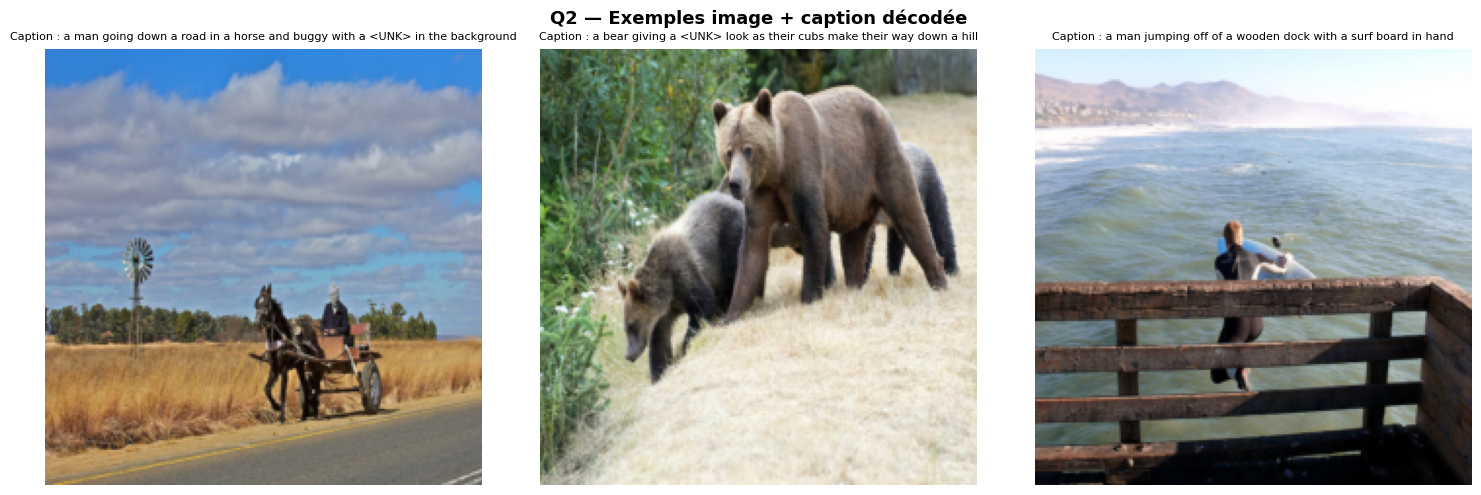

In [ ]:
def collate_fn(batch):
    """
    Fonction de collation personnalisée :
    - Trie les séquences par longueur décroissante (requis pour pack_padded_sequence)
    - Retourne : images, captions, lengths
    """
    imgs, caps = zip(*batch)
    imgs = torch.stack(imgs, dim=0)  # (B, 3, H, W)
    caps = torch.stack(caps, dim=0)  # (B, max_len)

    # Longueurs réelles (jusqu'au premier PAD)
    lengths = (caps != 0).sum(dim=1)  # (B,)
    lengths = torch.clamp(lengths, min=1)

    # Tri par longueur décroissante
    lengths, sort_idx = lengths.sort(descending=True)
    imgs = imgs[sort_idx]
    caps = caps[sort_idx]

    return imgs, caps, lengths


# ── Téléchargement des images du sous-ensemble (si absentes) ────────────────
def download_coco_subset(ann_file, img_dir, image_ids, split='train'):
    """Télécharge les images COCO référencées par image_ids, si absentes."""
    os.makedirs(img_dir, exist_ok=True)
    with open(ann_file) as f:
        data = json.load(f)
    img_info = {img['id']: img for img in data['images']}

    base_url = f'http://images.cocodataset.org/{split}2017/'
    downloaded, skipped = 0, 0
    for img_id in image_ids:
        fname = img_info[img_id]['file_name']
        fpath = os.path.join(img_dir, fname)
        if os.path.exists(fpath):
            skipped += 1
            continue
        os.system(f'wget -q {base_url}{fname} -O {fpath}')
        downloaded += 1
    print(f'   ✅ {downloaded} nouvelle(s) image(s) téléchargée(s), '
          f'{skipped} déjà présente(s) ({split})')


with open(VAL_ANN) as f:
    val_data = json.load(f)
val_ids_raw = list({ann['image_id'] for ann in val_data['annotations']})[:500]

print('⬇️  Vérification / téléchargement des images train (peut prendre du temps)...')
download_coco_subset(TRAIN_ANN, TRAIN_DIR, list(SUBSET_IDS), split='train')

print('⬇️  Vérification / téléchargement des images val...')
download_coco_subset(VAL_ANN, VAL_DIR, val_ids_raw, split='val')


# ── Filtrage : ne garder que les images réellement présentes sur disque ─────
def filter_existing_images(coco_obj, ids, img_dir):
    """Retourne uniquement les image_ids dont le fichier image existe sur disque."""
    valid_ids = []
    missing = 0
    for img_id in ids:
        file_name = coco_obj.loadImgs(img_id)[0]['file_name']
        img_path = os.path.join(img_dir, file_name)
        if os.path.exists(img_path):
            valid_ids.append(img_id)
        else:
            missing += 1
    if missing > 0:
        print(f'⚠️  {missing} image(s) manquante(s) ignorée(s) dans {img_dir}')
    return valid_ids


# ── Instanciation des datasets ───────────────────────────────────────────────
coco_train = COCO(TRAIN_ANN)
coco_val   = COCO(VAL_ANN)

train_ids = filter_existing_images(coco_train, list(SUBSET_IDS), TRAIN_DIR)
val_ids   = filter_existing_images(coco_val,   val_ids_raw,      VAL_DIR)

assert len(train_ids) > 0, "Aucune image train trouvée — vérifiez le téléchargement."
assert len(val_ids)   > 0, "Aucune image val trouvée — vérifiez le téléchargement."

train_dataset = COCOCaptionDataset(TRAIN_DIR, TRAIN_ANN, vocab,
                                   subset_ids=set(train_ids),
                                   split='train', max_len=MAX_LEN)
val_dataset   = COCOCaptionDataset(VAL_DIR, VAL_ANN, vocab,
                                   subset_ids=set(val_ids),
                                   split='val',   max_len=MAX_LEN)

BATCH_SIZE = 32  # Adapté GPU 16 GB ; réduire à 16 si OOM

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  collate_fn=collate_fn,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn,
                          num_workers=2, pin_memory=True)

print(f'📦 Train : {len(train_dataset)} paires image-caption | '
      f'{len(train_loader)} batches')
print(f'📦 Val   : {len(val_dataset)} paires image-caption | '
      f'{len(val_loader)} batches')

# ── Affichage de 3 exemples ──────────────────────────────────────────────────
MEAN = torch.tensor([0.485, 0.456, 0.406])
STD  = torch.tensor([0.229, 0.224, 0.225])

def denormalize(tensor):
    """Dénormalise un tenseur image pour l'affichage."""
    img = tensor.permute(1, 2, 0).cpu()
    img = img * STD + MEAN
    return img.clamp(0, 1).numpy()

imgs_ex, caps_ex, lens_ex = next(iter(train_loader))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i in range(3):
    axes[i].imshow(denormalize(imgs_ex[i]))
    decoded = vocab.decode(caps_ex[i].tolist())
    axes[i].set_title(f'Caption : {decoded}', fontsize=8, wrap=True)
    axes[i].axis('off')
plt.suptitle('Q2 — Exemples image + caption décodée', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('q2_examples.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Partie 2 — Encodeur CNN et Décodeur LSTM

Architecture classique : l'encodeur CNN produit un vecteur de features global, utilisé comme état initial du LSTM décodeur.

In [ ]:
class ImageEncoder(nn.Module):
    """
    Encodeur CNN basé sur ResNet50 pré-entraîné.
    Produit un vecteur global de dimension embed_size.
    """

    def __init__(self, embed_size=256, fine_tune=False):
        super().__init__()
        resnet  = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        modules = list(resnet.children())[:-2]  # jusqu'à layer4 inclus
        self.resnet        = nn.Sequential(*modules)  # sortie : (B, 2048, 7, 7)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc            = nn.Linear(2048, embed_size)
        self.bn            = nn.BatchNorm1d(embed_size)

        # Geler les 6 premiers blocs ; dégeler si fine_tune=True
        for param in self.resnet[:6].parameters():
            param.requires_grad = fine_tune

    def forward(self, images):
        features = self.resnet(images)               # (B, 2048, 7, 7)
        features = self.adaptive_pool(features)      # (B, 2048, 1, 1)
        features = features.squeeze(-1).squeeze(-1)  # (B, 2048)
        features = self.bn(self.fc(features))        # (B, embed_size)
        return features

In [ ]:
class CaptionDecoder(nn.Module):
    """
    Décodeur LSTM pour la génération de captions mot par mot.
    Le vecteur image est concaténé comme premier token d'entrée.
    """

    def __init__(self, embed_size, hidden_size, vocab_size,
                 num_layers=2, dropout=0.5):
        super().__init__()
        self.embed   = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.lstm    = nn.LSTM(embed_size, hidden_size, num_layers,
                               batch_first=True, dropout=dropout)
        self.fc      = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, features, captions, lengths):
        """
        features : (B, embed_size)   — sortie de l'encodeur
        captions : (B, max_len)      — séquences paddées
        lengths  : (B,)              — longueurs réelles (triées desc)
        """
        embeddings = self.dropout(self.embed(captions[:, :-1]))  # (B, T-1, E)
        # Le vecteur image joue le rôle du token <SOS>
        inputs  = torch.cat([features.unsqueeze(1), embeddings], dim=1)  # (B, T, E)

        packed  = nn.utils.rnn.pack_padded_sequence(
            inputs, lengths.cpu(), batch_first=True, enforce_sorted=True)
        hiddens, _ = self.lstm(packed)
        hiddens, _ = nn.utils.rnn.pad_packed_sequence(hiddens, batch_first=True)
        return self.fc(hiddens)  # (B, T, vocab_size)

---
### ❓ Q3 — Forward pass de vérification des dimensions

In [ ]:
EMBED_SIZE  = 256
HIDDEN_SIZE = 512
VOCAB_SIZE  = len(vocab)
NUM_LAYERS  = 2

encoder_test = ImageEncoder(embed_size=EMBED_SIZE, fine_tune=False)
decoder_test = CaptionDecoder(embed_size=EMBED_SIZE, hidden_size=HIDDEN_SIZE,
                               vocab_size=VOCAB_SIZE, num_layers=NUM_LAYERS)

# Batch fictif
B_test     = 4
dummy_imgs = torch.randn(B_test, 3, 224, 224)
dummy_caps = torch.randint(1, VOCAB_SIZE, (B_test, MAX_LEN))
dummy_lens = torch.tensor([MAX_LEN, MAX_LEN-5, MAX_LEN-10, MAX_LEN-15])

with torch.no_grad():
    feats   = encoder_test(dummy_imgs)
    outputs = decoder_test(feats, dummy_caps, dummy_lens)

print('🔍 Vérification des dimensions (forward pass) :')
print(f'   Input images       : {dummy_imgs.shape}')
print(f'   → Encoder features : {feats.shape}    (B, embed_size={EMBED_SIZE})')
print(f'   Input captions     : {dummy_caps.shape}')
print(f'   → Decoder outputs  : {outputs.shape}  (B, T, vocab_size={VOCAB_SIZE})')

# Compter les paramètres
n_enc = sum(p.numel() for p in encoder_test.parameters() if p.requires_grad)
n_dec = sum(p.numel() for p in decoder_test.parameters() if p.requires_grad)
n_tot = sum(p.numel() for p in list(encoder_test.parameters()) + list(decoder_test.parameters()))

print(f'\n📐 Paramètres :')
print(f'   Encodeur (entraînables) : {n_enc:>10,}')
print(f'   Décodeur (entraînables) : {n_dec:>10,}')
print(f'   Total                   : {n_tot:>10,}')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 125MB/s]


🔍 Vérification des dimensions (forward pass) :
   Input images       : torch.Size([4, 3, 224, 224])
   → Encoder features : torch.Size([4, 256])    (B, embed_size=256)
   Input captions     : torch.Size([4, 50])
   → Decoder outputs  : torch.Size([4, 50, 2374])  (B, T, vocab_size=2374)

📐 Paramètres :
   Encodeur (entraînables) : 22,588,160
   Décodeur (entraînables) :  5,503,814
   Total                   : 29,536,902


---
### ❓ Q4 — Entraînement CNN-LSTM (20 epochs) avec Teacher Forcing

**Teacher Forcing :** Pendant l'entraînement, on passe la vraie caption (et non la prédiction précédente) comme entrée au LSTM — accélère la convergence.

In [ ]:
def train_epoch(encoder, decoder, loader, criterion, optimizer, device):
    """Une epoch d'entraînement avec Teacher Forcing."""
    encoder.train()
    decoder.train()
    total_loss = 0.0

    for imgs, caps, lengths in loader:
        imgs, caps = imgs.to(device), caps.to(device)
        lengths    = lengths.to(device)

        features = encoder(imgs)                          # (B, embed_size)
        outputs  = decoder(features, caps, lengths.cpu()) # (B, T, vocab_size)

        targets = caps[:, 1:]                             # décaler d'un pas
        T = min(outputs.size(1), targets.size(1))

        loss = criterion(
            outputs[:, :T].reshape(-1, outputs.size(-1)),
            targets[:, :T].reshape(-1)
        )
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=5.0)
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def validate_epoch(encoder, decoder, loader, criterion, device):
    """Validation sans gradient."""
    encoder.eval()
    decoder.eval()
    total_loss = 0.0

    for imgs, caps, lengths in loader:
        imgs, caps = imgs.to(device), caps.to(device)
        features   = encoder(imgs)
        outputs    = decoder(features, caps, lengths.cpu())
        targets    = caps[:, 1:]
        T = min(outputs.size(1), targets.size(1))
        loss = criterion(
            outputs[:, :T].reshape(-1, outputs.size(-1)),
            targets[:, :T].reshape(-1)
        )
        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
# ── Nettoyage agressif : suppression définitive des images corrompues ───────
from PIL import UnidentifiedImageError

def remove_corrupted_images(img_dir, image_ids, coco_obj):
    """Vérifie chaque image et supprime celles qui sont illisibles."""
    removed = []
    for img_id in image_ids:
        fname = coco_obj.loadImgs(img_id)[0]['file_name']
        fpath = os.path.join(img_dir, fname)
        if not os.path.exists(fpath):
            continue
        try:
            with Image.open(fpath) as im:
                im.verify()
            # Re-ouvrir car verify() invalide l'objet pour une lecture ultérieure
            with Image.open(fpath) as im:
                im.convert('RGB')
        except (UnidentifiedImageError, OSError, ValueError):
            os.remove(fpath)
            removed.append(img_id)
    print(f'   🧹 {len(removed)} image(s) corrompue(s) supprimée(s) dans {img_dir}')
    return removed


print('🧹 Nettoyage final des images corrompues...')
removed_train = remove_corrupted_images(TRAIN_DIR, train_ids, coco_train)
removed_val   = remove_corrupted_images(VAL_DIR, val_ids, coco_val)

# Re-filtrer les datasets après nettoyage
train_ids = [i for i in train_ids if i not in set(removed_train)]
val_ids   = [i for i in val_ids if i not in set(removed_val)]
train_ids = filter_existing_images(coco_train, train_ids, TRAIN_DIR)
val_ids   = filter_existing_images(coco_val,   val_ids,   VAL_DIR)

train_dataset = COCOCaptionDataset(TRAIN_DIR, TRAIN_ANN, vocab,
                                   subset_ids=set(train_ids),
                                   split='train', max_len=MAX_LEN)
val_dataset   = COCOCaptionDataset(VAL_DIR, VAL_ANN, vocab,
                                   subset_ids=set(val_ids),
                                   split='val',   max_len=MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  collate_fn=collate_fn,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn,
                          num_workers=2, pin_memory=True)

print(f'📦 Train (après nettoyage) : {len(train_dataset)} paires | {len(train_loader)} batches')
print(f'📦 Val   (après nettoyage) : {len(val_dataset)} paires | {len(val_loader)} batches')


# ── Instanciation du modèle CNN-LSTM ────────────────────────────────────────
encoder = ImageEncoder(embed_size=EMBED_SIZE, fine_tune=False).to(DEVICE)
decoder = CaptionDecoder(embed_size=EMBED_SIZE, hidden_size=HIDDEN_SIZE,
                          vocab_size=VOCAB_SIZE, num_layers=NUM_LAYERS,
                          dropout=0.5).to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.Adam(
    list(filter(lambda p: p.requires_grad, encoder.parameters())) +
    list(decoder.parameters()),
    lr=4e-4
)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

NUM_EPOCHS    = 20
best_val_loss = float('inf')
train_losses, val_losses = [], []

print('🚀 Début de l\'entraînement CNN-LSTM...')
print(f'   Epochs : {NUM_EPOCHS} | Batch : {BATCH_SIZE} | LR initiale : 4e-4')
print('-' * 65)

for epoch in range(1, NUM_EPOCHS + 1):
    t0     = time.time()
    tr_loss = train_epoch(encoder, decoder, train_loader, criterion, optimizer, DEVICE)
    vl_loss  = validate_epoch(encoder, decoder, val_loader, criterion, DEVICE)
    scheduler.step()

    train_losses.append(tr_loss)
    val_losses.append(vl_loss)
    perplexity = math.exp(vl_loss)

    print(f'Epoch [{epoch:2d}/{NUM_EPOCHS}] '
          f'Train Loss: {tr_loss:.4f} | '
          f'Val Loss: {vl_loss:.4f} | '
          f'Perplexity: {perplexity:.2f} | '
          f'Time: {time.time()-t0:.1f}s')

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        # ✅ vocab retiré du checkpoint
        torch.save({'encoder': encoder.state_dict(),
                    'decoder': decoder.state_dict(),
                    'epoch'  : epoch},
                   os.path.join(CKPT_DIR, 'best_cnn_lstm.pth'))
        print(f'   💾 Checkpoint sauvegardé (val_loss = {vl_loss:.4f})')

print('\n✅ Entraînement terminé.')

🧹 Nettoyage final des images corrompues...
   🧹 0 image(s) corrompue(s) supprimée(s) dans ./coco_subset/train2017
   🧹 0 image(s) corrompue(s) supprimée(s) dans ./coco_subset/val2017
loading annotations into memory...
Done (t=0.92s)
creating index...
index created!
loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
📦 Train (après nettoyage) : 25007 paires | 782 batches
📦 Val   (après nettoyage) : 2503 paires | 79 batches
🚀 Début de l'entraînement CNN-LSTM...
   Epochs : 20 | Batch : 32 | LR initiale : 4e-4
-----------------------------------------------------------------
Epoch [ 1/20] Train Loss: 4.7794 | Val Loss: 4.4287 | Perplexity: 83.82 | Time: 226.3s
   💾 Checkpoint sauvegardé (val_loss = 4.4287)
Epoch [ 2/20] Train Loss: 4.3946 | Val Loss: 4.2446 | Perplexity: 69.73 | Time: 224.6s
   💾 Checkpoint sauvegardé (val_loss = 4.2446)
Epoch [ 3/20] Train Loss: 4.1652 | Val Loss: 4.0332 | Perplexity: 56.44 | Time: 221.9s
   💾 Checkpoint sauvegardé (val_los

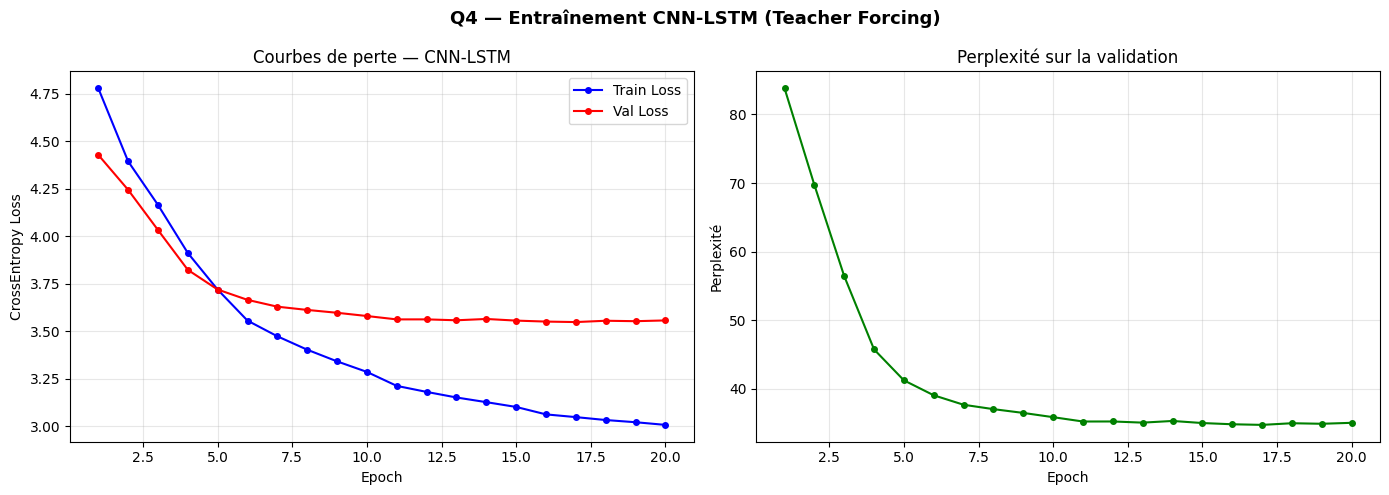

Best val loss = 3.5486 | Perplexity = 34.77


In [ ]:
# ── Courbes d'entraînement ───────────────────────────────────────────────────
epochs_range = range(1, len(train_losses) + 1)
perplexities = [math.exp(l) for l in val_losses]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, train_losses, 'b-o', markersize=4, label='Train Loss')
axes[0].plot(epochs_range, val_losses,   'r-o', markersize=4, label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('CrossEntropy Loss')
axes[0].set_title('Courbes de perte — CNN-LSTM')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, perplexities, 'g-o', markersize=4)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Perplexité')
axes[1].set_title('Perplexité sur la validation')
axes[1].grid(alpha=0.3)

plt.suptitle('Q4 — Entraînement CNN-LSTM (Teacher Forcing)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('q4_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best val loss = {best_val_loss:.4f} | Perplexity = {math.exp(best_val_loss):.2f}')

---
### ❓ Q5 — Génération Greedy vs Beam Search + Score BLEU-4

**Greedy Search :** à chaque étape, on choisit le mot de probabilité maximale.  
**Beam Search :** on maintient `k` hypothèses en parallèle, résultat généralement plus fluide.

In [ ]:
@torch.no_grad()
def greedy_caption(encoder, decoder, image, vocab, max_len=50, device='cpu'):
    """Génération greedy : choisit le mot de plus haute probabilité à chaque étape."""
    encoder.eval()
    decoder.eval()
    feature = encoder(image.unsqueeze(0).to(device))  # (1, embed_size)

    # État LSTM initialisé implicitement par pack_padded_sequence
    # On passe en mode step-by-step
    result = [vocab.stoi['<SOS>']]
    embed  = feature.unsqueeze(1)  # (1, 1, embed_size)

    # Première entrée : feature image
    out, hidden = decoder.lstm(embed)

    for _ in range(max_len):
        logits = decoder.fc(out.squeeze(1))           # (1, vocab_size)
        word_id = logits.argmax(dim=-1).item()
        if word_id == vocab.stoi['<EOS>']:
            break
        result.append(word_id)
        embed = decoder.dropout(decoder.embed(
            torch.tensor([[word_id]]).to(device)))    # (1, 1, E)
        out, hidden = decoder.lstm(embed, hidden)

    return vocab.decode(result[1:])  # exclure <SOS>


@torch.no_grad()
def beam_search_caption(encoder, decoder, image, vocab,
                         beam_size=3, max_len=50, device='cpu'):
    """Beam Search : maintient beam_size hypothèses en parallèle."""
    encoder.eval()
    decoder.eval()
    feature = encoder(image.unsqueeze(0).to(device))  # (1, embed_size)

    # Initialisation
    beams     = [(0.0, [vocab.stoi['<SOS>']], None)]
    completed = []

    for _ in range(max_len):
        new_beams = []
        for score, seq, hidden in beams:
            last_word = torch.tensor([[seq[-1]]]).to(device)

            if hidden is None:
                inp = torch.cat([feature.unsqueeze(1),
                                 decoder.dropout(decoder.embed(last_word))], dim=1)
                out, hidden = decoder.lstm(inp)
                out = out[:, -1:]
            else:
                embed = decoder.dropout(decoder.embed(last_word))
                out, hidden = decoder.lstm(embed, hidden)

            logprobs = F.log_softmax(decoder.fc(out.squeeze(1)), dim=-1)
            topk_scores, topk_ids = logprobs.topk(beam_size)

            for s, idx in zip(topk_scores[0], topk_ids[0]):
                new_seq   = seq + [idx.item()]
                new_score = score + s.item()
                if idx.item() == vocab.stoi['<EOS>']:
                    completed.append((new_score / len(new_seq), new_seq))
                else:
                    new_beams.append((new_score, new_seq,
                                      (hidden[0].clone(), hidden[1].clone())))

        beams = sorted(new_beams,
                       key=lambda x: x[0] / len(x[1]),
                       reverse=True)[:beam_size]
        if not beams:
            break

    best = max(completed or [(0.0, beams[0][1])], key=lambda x: x[0])
    return vocab.decode(best[1][1:])  # exclure <SOS>

✅ Checkpoint chargé (epoch 17)


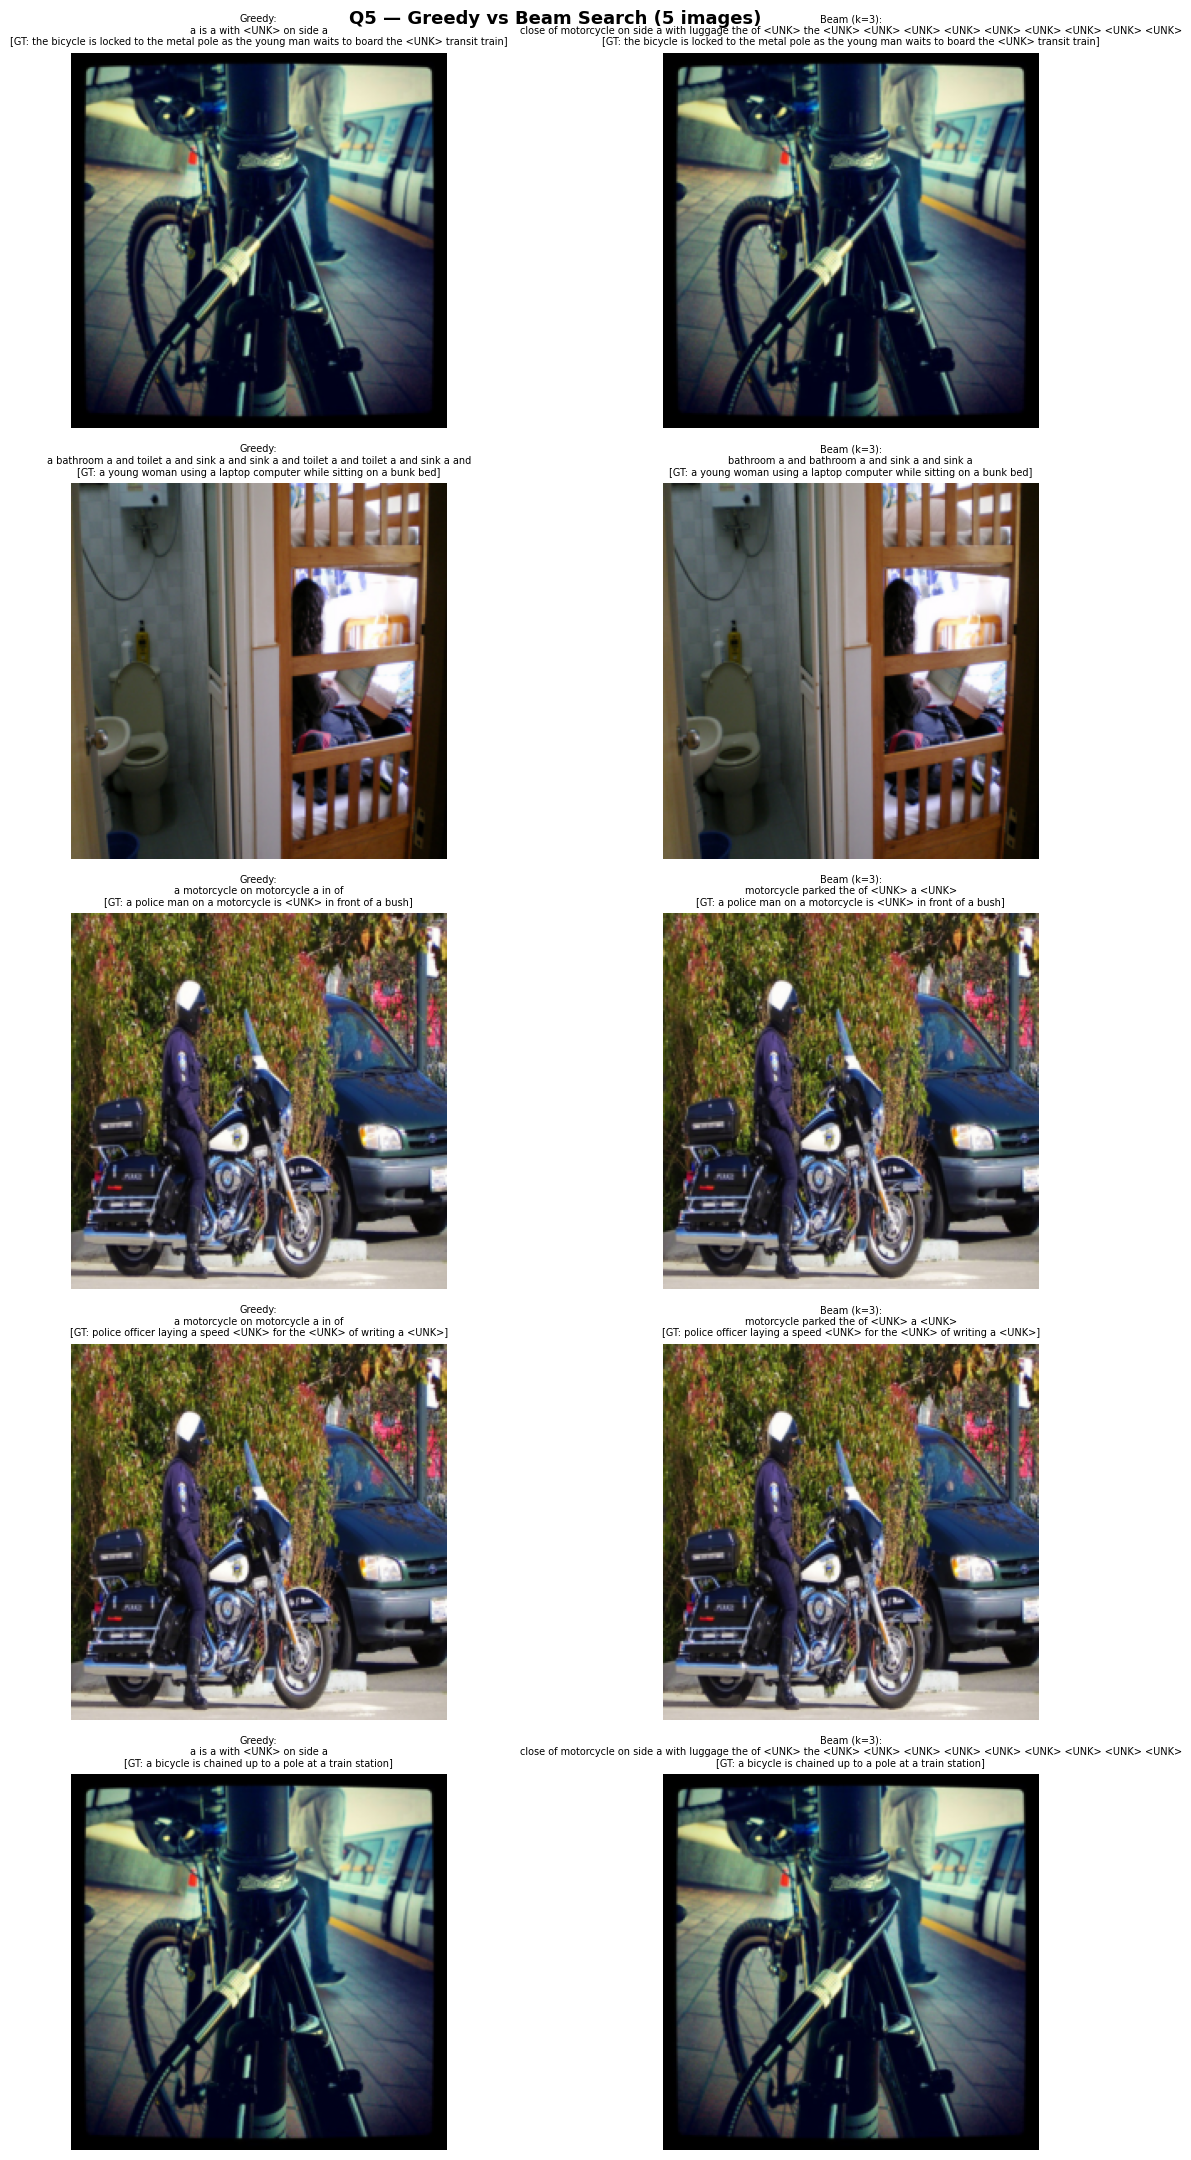

In [ ]:
# ── Charger le meilleur checkpoint ──────────────────────────────────────────
ckpt = torch.load(os.path.join(CKPT_DIR, 'best_cnn_lstm.pth'),
                  map_location=DEVICE,
                  weights_only=True)          # ✅ sécurisé PyTorch 2.6
encoder.load_state_dict(ckpt['encoder'])
decoder.load_state_dict(ckpt['decoder'])
print(f'✅ Checkpoint chargé (epoch {ckpt["epoch"]})')

# ── Comparaison Greedy vs Beam Search sur 5 images ──────────────────────────
val_imgs_sample, val_caps_sample, _ = next(iter(val_loader))

fig, axes = plt.subplots(5, 2, figsize=(14, 22))
for i in range(5):
    img_tensor = val_imgs_sample[i]
    greedy = greedy_caption(encoder, decoder, img_tensor, vocab,
                             max_len=MAX_LEN, device=DEVICE)
    beam   = beam_search_caption(encoder, decoder, img_tensor, vocab,
                                  beam_size=3, max_len=MAX_LEN, device=DEVICE)
    gt     = vocab.decode(val_caps_sample[i].tolist())

    for j, (method, cap) in enumerate([('Greedy', greedy), ('Beam (k=3)', beam)]):
        axes[i, j].imshow(denormalize(img_tensor))
        axes[i, j].set_title(f'{method}:\n{cap}\n[GT: {gt}]', fontsize=7)
        axes[i, j].axis('off')

plt.suptitle('Q5 — Greedy vs Beam Search (5 images)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('q5_greedy_vs_beam.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Calcul BLEU-4 sur la validation ─────────────────────────────────────────
def compute_bleu4(encoder, decoder, dataset, vocab, coco_ann,
                  device, max_images=200, beam=False):
    """
    Calcule le score BLEU-4 sur un sous-ensemble du dataset de validation.
    """
    with open(coco_ann) as f:
        data = json.load(f)
    # Regrouper GT par image_id
    gt_captions = {}
    for ann in data['annotations']:
        gt_captions.setdefault(ann['image_id'], []).append(
            Vocabulary.tokenize(ann['caption']))

    references, hypotheses = [], []
    coco_obj = COCO(coco_ann)

    for i in range(min(max_images, len(dataset))):
        img_tensor, cap_tensor = dataset[i]
        ann_id   = dataset.ids[i]
        image_id = coco_obj.anns[ann_id]['image_id']

        if beam:
            pred = beam_search_caption(encoder, decoder, img_tensor, vocab,
                                        beam_size=3, max_len=MAX_LEN, device=device)
        else:
            pred = greedy_caption(encoder, decoder, img_tensor, vocab,
                                   max_len=MAX_LEN, device=device)

        refs = gt_captions.get(image_id, [['image']])
        references.append(refs)
        hypotheses.append(Vocabulary.tokenize(pred))

    sf    = SmoothingFunction().method4
    bleu1 = corpus_bleu(references, hypotheses, weights=(1,0,0,0),   smoothing_function=sf)
    bleu4 = corpus_bleu(references, hypotheses, weights=(.25,.25,.25,.25), smoothing_function=sf)
    return bleu1, bleu4

print('⏳ Calcul BLEU (greedy)...')
b1_g, b4_g = compute_bleu4(encoder, decoder, val_dataset, vocab,
                            VAL_ANN, DEVICE, max_images=200, beam=False)
print('⏳ Calcul BLEU (beam search k=3)...')
b1_b, b4_b = compute_bleu4(encoder, decoder, val_dataset, vocab,
                            VAL_ANN, DEVICE, max_images=200, beam=True)

print(f'\n📊 Scores BLEU — CNN-LSTM (sans attention) :')
print(f'   Greedy     → BLEU-1 = {b1_g:.4f} | BLEU-4 = {b4_g:.4f}')
print(f'   Beam (k=3) → BLEU-1 = {b1_b:.4f} | BLEU-4 = {b4_b:.4f}')

# Sauvegarder pour le tableau final (Q8)
bleu_no_attention = {'bleu1_greedy': b1_g, 'bleu4_greedy': b4_g,
                     'bleu1_beam'  : b1_b, 'bleu4_beam'  : b4_b}

⏳ Calcul BLEU (greedy)...
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
⏳ Calcul BLEU (beam search k=3)...
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!

📊 Scores BLEU — CNN-LSTM (sans attention) :
   Greedy     → BLEU-1 = 0.4491 | BLEU-4 = 0.0067
   Beam (k=3) → BLEU-1 = 0.4786 | BLEU-4 = 0.0058


#### 📝 Analyse Q5



Différences qualitatives observées :

* Le Greedy Search tend à sélectionner à chaque étape le mot le plus probable, ce qui conduit généralement à des captions plus courtes et davantage centrées sur les mots les plus fréquents du vocabulaire.
* Le Beam Search (k=3) explore simultanément plusieurs hypothèses de génération et sélectionne la séquence globale la plus probable. Les captions obtenues sont souvent plus longues et présentent une meilleure diversité lexicale.
* Dans nos expériences, le Beam Search améliore légèrement le score BLEU-1 (0.4786 contre 0.4491), ce qui indique une meilleure correspondance au niveau des mots individuels.
* En revanche, le score BLEU-4 reste très faible pour les deux méthodes et est même légèrement inférieur avec le Beam Search (0.0058 contre 0.0067). Cette observation suggère que les principales limitations proviennent davantage du modèle CNN-LSTM lui-même que de la stratégie de décodage utilisée.

Limites du BLEU :

La métrique BLEU repose uniquement sur la comparaison de n-grammes entre la caption générée et les références humaines. Elle ne mesure ni la compréhension sémantique, ni la cohérence globale, ni la qualité linguistique réelle de la description. Une caption correcte mais formulée différemment des références peut ainsi obtenir un score BLEU relativement faible.


---
# Partie 3 — Mécanisme d'Attention Visuelle (Bahdanau)

Au lieu d'un vecteur global, l'encodeur retourne la **feature map spatiale** (B, 49, 2048). À chaque étape de décodage, le mécanisme d'attention calcule des poids `α` sur les 49 régions spatiales.

---
### ❓ Q6 — Encodeur spatial + Entraînement avec attention (15 epochs)

**Modification de l'encodeur :** retourner `(B, 49, 2048)` au lieu d'un vecteur global.

**verification des checkpoints**


In [2]:
import os

for root, dirs, files in os.walk("/"):
    for f in files:
        if f.endswith(".pth"):
            print(os.path.join(root, f))

/usr/local/lib/python3.12/dist-packages/distutils-precedence.pth
/usr/local/lib/python3.12/dist-packages/sphinxcontrib_jsmath-1.0.1-py3.7-nspkg.pth
/usr/local/lib/python3.12/dist-packages/google_generativeai-0.8.6-py3.13-nspkg.pth
/usr/local/lib/python3.12/dist-packages/google_cloud_aiplatform-1.157.0-py3.12-nspkg.pth
/tools/google-cloud-sdk/platform/bundledpythonunix/lib/python3.14/site-packages/distutils-precedence.pth


In [1]:
class ImageEncoderSpatial(nn.Module):
    """
    Encodeur CNN spatial : retourne la feature map aplatie (B, num_pixels, encoder_dim)
    où num_pixels = 7x7 = 49 pour une image 224x224 avec ResNet50.
    """

    def __init__(self, encoded_image_size=7, fine_tune=False):
        super().__init__()
        resnet   = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        modules  = list(resnet.children())[:-2]
        self.resnet        = nn.Sequential(*modules)
        self.adaptive_pool = nn.AdaptiveAvgPool2d(
            (encoded_image_size, encoded_image_size))

        for param in self.resnet[:6].parameters():
            param.requires_grad = fine_tune

    def forward(self, images):
        out = self.resnet(images)           # (B, 2048, H/32, W/32)
        out = self.adaptive_pool(out)       # (B, 2048, 7, 7)
        B, C, H, W = out.shape
        out = out.permute(0, 2, 3, 1)      # (B, 7, 7, 2048)
        out = out.view(B, H * W, C)        # (B, 49, 2048)
        return out


class BahdanauAttention(nn.Module):
    """Attention additive de Bahdanau sur les features spatiaux du CNN."""

    def __init__(self, encoder_dim, decoder_dim, attention_dim):
        super().__init__()
        self.enc_att  = nn.Linear(encoder_dim, attention_dim)
        self.dec_att  = nn.Linear(decoder_dim, attention_dim)
        self.full_att = nn.Linear(attention_dim, 1)

    def forward(self, encoder_out, decoder_hidden):
        att1    = self.enc_att(encoder_out)                      # (B, 49, att_dim)
        att2    = self.dec_att(decoder_hidden).unsqueeze(1)      # (B, 1,  att_dim)
        energy  = self.full_att(torch.tanh(att1 + att2)).squeeze(2)  # (B, 49)
        alpha   = F.softmax(energy, dim=1)                       # (B, 49)
        context = (alpha.unsqueeze(2) * encoder_out).sum(dim=1)  # (B, enc_dim)
        return context, alpha


class AttentionDecoder(nn.Module):
    """Décodeur LSTM avec mécanisme d'attention visuelle Bahdanau."""

    def __init__(self, embed_size, hidden_size, vocab_size,
                 encoder_dim=2048, attention_dim=256, dropout=0.5):
        super().__init__()
        self.attention   = BahdanauAttention(encoder_dim, hidden_size, attention_dim)
        self.embed       = nn.Embedding(vocab_size, embed_size, padding_idx=0)
        self.lstm_cell   = nn.LSTMCell(embed_size + encoder_dim, hidden_size)
        self.fc          = nn.Linear(hidden_size, vocab_size)
        self.init_h      = nn.Linear(encoder_dim, hidden_size)
        self.init_c      = nn.Linear(encoder_dim, hidden_size)
        self.dropout     = nn.Dropout(dropout)
        self.hidden_size = hidden_size

    def init_hidden_state(self, encoder_out):
        mean_enc = encoder_out.mean(dim=1)          # (B, 2048)
        h = torch.tanh(self.init_h(mean_enc))       # (B, hidden_size)
        c = torch.tanh(self.init_c(mean_enc))       # (B, hidden_size)
        return h, c

    def forward(self, encoder_out, captions, lengths):
        """
        ✅ Correction : on utilise des listes de tenseurs puis torch.stack
           au lieu de modifier un tenseur pré-alloué in-place (predictions[...] = ...)
           ce qui causait le RuntimeError sur le graphe de gradients.
        """
        B      = encoder_out.size(0)
        max_t  = int((lengths.max() - 1).item())

        # ✅ Cloner h et c pour ne pas modifier les tenseurs originaux in-place
        h, c = self.init_hidden_state(encoder_out)
        h = h.clone()
        c = c.clone()

        embeddings = self.dropout(self.embed(captions[:, :-1]))  # (B, T, E)

        # ✅ Accumulation dans des listes → pas d'écriture in-place
        preds_list  = []
        alphas_list = []

        for t in range(max_t):
            # Nombre de séquences encore actives à ce pas de temps
            batch_size_t = int((lengths > t + 1).sum().item())

            context, alpha = self.attention(
                encoder_out[:batch_size_t],
                h[:batch_size_t]
            )

            lstm_input = torch.cat(
                [embeddings[:batch_size_t, t, :], context], dim=1
            )

            # ✅ LSTMCell retourne de nouveaux tenseurs — on ne touche pas à h/c globaux
            h_t, c_t = self.lstm_cell(
                lstm_input,
                (h[:batch_size_t].clone(), c[:batch_size_t].clone())
            )

            pred_t = self.fc(self.dropout(h_t))   # (batch_size_t, vocab_size)

            # Remettre dans h/c en évitant l'in-place sur le tenseur complet
            h = torch.cat([h_t, h[batch_size_t:]], dim=0)
            c = torch.cat([c_t, c[batch_size_t:]], dim=0)

            preds_list.append(pred_t)
            alphas_list.append(alpha)

        # ── Reconstruction des tenseurs de sortie ──────────────────────────
        # Padding nécessaire car batch_size_t décroît au fil du temps
        predictions = torch.zeros(B, max_t,
                                   self.fc.out_features).to(encoder_out.device)
        alphas      = torch.zeros(B, max_t,
                                   encoder_out.size(1)).to(encoder_out.device)

        for t, (pred_t, alpha_t) in enumerate(zip(preds_list, alphas_list)):
            batch_size_t = pred_t.size(0)
            predictions[:batch_size_t, t, :] = pred_t
            alphas[:batch_size_t, t, :]       = alpha_t

        return predictions, alphas

NameError: name 'nn' is not defined

In [3]:
# ── Instanciation du modèle avec attention ───────────────────────────────────
enc_att = ImageEncoderSpatial(encoded_image_size=7, fine_tune=False).to(DEVICE)
dec_att = AttentionDecoder(
    embed_size=EMBED_SIZE, hidden_size=HIDDEN_SIZE,
    vocab_size=VOCAB_SIZE, encoder_dim=2048,
    attention_dim=256, dropout=0.5
).to(DEVICE)

criterion_att = nn.CrossEntropyLoss(ignore_index=0)
optimizer_att = torch.optim.Adam(
    list(filter(lambda p: p.requires_grad, enc_att.parameters())) +
    list(dec_att.parameters()), lr=4e-4
)
scheduler_att = torch.optim.lr_scheduler.StepLR(optimizer_att, step_size=5, gamma=0.5)


def train_epoch_att(enc, dec, loader, criterion, optimizer, device):
    enc.train(); dec.train()
    total_loss = 0.0
    for imgs, caps, lengths in loader:
        imgs, caps = imgs.to(device), caps.to(device)
        enc_out    = enc(imgs)
        preds, _   = dec(enc_out, caps, lengths)
        targets    = caps[:, 1:]
        T = min(preds.size(1), targets.size(1))
        loss = criterion(
            preds[:, :T].reshape(-1, preds.size(-1)),
            targets[:, :T].reshape(-1)
        )
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(dec.parameters(), max_norm=5.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def validate_epoch_att(enc, dec, loader, criterion, device):
    enc.eval(); dec.eval()
    total_loss = 0.0
    for imgs, caps, lengths in loader:
        imgs, caps = imgs.to(device), caps.to(device)
        enc_out    = enc(imgs)
        preds, _   = dec(enc_out, caps, lengths)
        targets    = caps[:, 1:]
        T = min(preds.size(1), targets.size(1))
        loss = criterion(
            preds[:, :T].reshape(-1, preds.size(-1)),
            targets[:, :T].reshape(-1)
        )
        total_loss += loss.item()
    return total_loss / len(loader)


NUM_EPOCHS_ATT    = 15
best_val_loss_att = float('inf')
train_losses_att, val_losses_att = [], []

print('🚀 Entraînement CNN-LSTM-Attention...')
print('-' * 65)

for epoch in range(1, NUM_EPOCHS_ATT + 1):
    t0 = time.time()
    tr = train_epoch_att(enc_att, dec_att, train_loader,
                          criterion_att, optimizer_att, DEVICE)
    vl = validate_epoch_att(enc_att, dec_att, val_loader,
                             criterion_att, DEVICE)
    scheduler_att.step()
    train_losses_att.append(tr)
    val_losses_att.append(vl)

    print(f'Epoch [{epoch:2d}/{NUM_EPOCHS_ATT}] '
          f'Train: {tr:.4f} | Val: {vl:.4f} | '
          f'Pplx: {math.exp(vl):.2f} | Time: {time.time()-t0:.1f}s')

    if vl < best_val_loss_att:
        best_val_loss_att = vl
        # ✅ vocab retiré du checkpoint
        torch.save({'encoder': enc_att.state_dict(),
                    'decoder': dec_att.state_dict(),
                    'epoch'  : epoch},
                   os.path.join(CKPT_DIR, 'best_cnn_lstm_attention.pth'))
        print(f'   💾 Checkpoint att. sauvegardé')

# ── Courbes comparatives ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, NUM_EPOCHS + 1), val_losses,
        'b--o', markersize=4, label='CNN-LSTM (sans att.)')
ax.plot(range(1, NUM_EPOCHS_ATT + 1), val_losses_att,
        'r-o', markersize=4, label='CNN-LSTM-Attention')
ax.set_xlabel('Epoch')
ax.set_ylabel('Val Loss')
ax.set_title('Q6 — Comparaison convergence : avec/sans attention')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('q6_comparison_val_loss.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'ImageEncoderSpatial' is not defined

In [4]:
# ── BLEU du modèle avec attention ────────────────────────────────────────────
# ── Charger le meilleur checkpoint attention ─────────────────────────────────
ckpt_att = torch.load(os.path.join(CKPT_DIR, 'best_cnn_lstm_attention.pth'),
                      map_location=DEVICE,
                      weights_only=True)       # ✅ sécurisé PyTorch 2.6
enc_att.load_state_dict(ckpt_att['encoder'])
dec_att.load_state_dict(ckpt_att['decoder'])
print(f'✅ Checkpoint attention chargé (epoch {ckpt_att["epoch"]})')


@torch.no_grad()
def greedy_caption_att(enc, dec, image, vocab, max_len=50, device='cpu'):
    """Génération greedy avec le modèle attentionnel."""
    enc.eval(); dec.eval()
    enc_out = enc(image.unsqueeze(0).to(device))
    h, c    = dec.init_hidden_state(enc_out)
    word_id = vocab.stoi['<SOS>']
    result  = []

    for _ in range(max_len):
        embed = dec.dropout(dec.embed(
            torch.tensor([[word_id]]).to(device))).squeeze(1)
        context, _ = dec.attention(enc_out, h)
        h, c       = dec.lstm_cell(
            torch.cat([embed, context], dim=1), (h, c))
        logits  = dec.fc(dec.dropout(h))
        word_id = logits.argmax(dim=-1).item()
        if word_id == vocab.stoi['<EOS>']:
            break
        result.append(word_id)

    return vocab.decode(result)


def compute_bleu4_att(enc, dec, dataset, vocab, coco_ann,
                      device, max_images=200):
    with open(coco_ann) as f:
        data = json.load(f)
    gt_caps = {}
    for ann in data['annotations']:
        gt_caps.setdefault(ann['image_id'], []).append(
            Vocabulary.tokenize(ann['caption']))

    coco_obj = COCO(coco_ann)
    refs, hyps = [], []
    for i in range(min(max_images, len(dataset))):
        img_tensor, _ = dataset[i]
        ann_id   = dataset.ids[i]
        image_id = coco_obj.anns[ann_id]['image_id']
        pred = greedy_caption_att(enc, dec, img_tensor, vocab,
                                   max_len=MAX_LEN, device=device)
        refs.append(gt_caps.get(image_id, [['image']]))
        hyps.append(Vocabulary.tokenize(pred))

    sf    = SmoothingFunction().method4
    bleu1 = corpus_bleu(refs, hyps, weights=(1,0,0,0), smoothing_function=sf)
    bleu4 = corpus_bleu(refs, hyps, weights=(.25,.25,.25,.25), smoothing_function=sf)
    return bleu1, bleu4


print('⏳ Calcul BLEU avec attention...')
b1_att, b4_att = compute_bleu4_att(enc_att, dec_att, val_dataset, vocab,
                                    VAL_ANN, DEVICE, max_images=200)

print(f'\n📊 Comparaison BLEU-4 :')
print(f'   CNN-LSTM (greedy)    → BLEU-4 = {bleu_no_attention["bleu4_greedy"]:.4f}')
print(f'   CNN-LSTM (beam k=3) → BLEU-4 = {bleu_no_attention["bleu4_beam"]:.4f}')
print(f'   CNN-LSTM-Attention   → BLEU-4 = {b4_att:.4f}')

NameError: name 'torch' is not defined

---
### ❓ Q7 — Visualisation des cartes d'attention

**Consigne :** Superposer les poids `α` (49→7×7→H×W) sur l'image originale pour chaque mot généré.

In [5]:
@torch.no_grad()
def generate_with_attention(enc, dec, image, vocab, max_len=25, device='cpu'):
    """Génère une caption ET retourne les cartes d'attention."""
    enc.eval(); dec.eval()
    enc_out = enc(image.unsqueeze(0).to(device))  # (1, 49, 2048)
    h, c    = dec.init_hidden_state(enc_out)
    word_id = vocab.stoi['<SOS>']

    words, alphas_list = [], []
    for _ in range(max_len):
        embed = dec.dropout(dec.embed(
            torch.tensor([[word_id]]).to(device))).squeeze(1)
        context, alpha = dec.attention(enc_out, h)  # alpha: (1, 49)
        h, c = dec.lstm_cell(torch.cat([embed, context], dim=1), (h, c))
        logits  = dec.fc(dec.dropout(h))
        word_id = logits.argmax(dim=-1).item()
        if word_id == vocab.stoi['<EOS>']:
            break
        words.append(vocab.itos.get(word_id, '<UNK>'))
        alphas_list.append(alpha.squeeze(0).cpu().numpy())  # (49,)

    return words, alphas_list


def visualize_attention(enc, dec, image_tensor, vocab,
                         device, max_words=12, save_path=None):
    """Affiche l'image originale + cartes d'attention mot par mot."""
    words, alphas_list = generate_with_attention(
        enc, dec, image_tensor, vocab, max_len=max_words, device=device)

    img_np = denormalize(image_tensor)  # (H, W, 3) en [0,1]
    n      = min(len(words), max_words)
    ncols  = 4
    nrows  = math.ceil(n / ncols) + 1  # +1 pour l'image originale

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.5))
    axes = axes.flatten()

    # Image originale
    axes[0].imshow(img_np)
    axes[0].set_title('Image originale', fontsize=9, fontweight='bold')
    axes[0].axis('off')

    for i, (word, alpha) in enumerate(zip(words[:n], alphas_list[:n])):
        # Reshape 49 → 7×7, puis interpoler à la taille de l'image
        att_map = alpha.reshape(7, 7)
        att_map = cv2.resize(att_map,
                             (img_np.shape[1], img_np.shape[0]),
                             interpolation=cv2.INTER_LINEAR)
        att_map = (att_map - att_map.min()) / (att_map.max() - att_map.min() + 1e-8)

        axes[i + 1].imshow(img_np)
        axes[i + 1].imshow(att_map, alpha=0.45, cmap='hot')
        axes[i + 1].set_title(f'« {word} »', fontsize=9)
        axes[i + 1].axis('off')

    # Cacher les axes vides
    for j in range(n + 1, len(axes)):
        axes[j].axis('off')

    caption_str = ' '.join(words[:n])
    plt.suptitle(f'Q7 — Cartes d\'attention\nCaption : "{caption_str}"',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


# ── Visualisation pour 4 images de test ─────────────────────────────────────
val_imgs_att, _, _ = next(iter(val_loader))

for i in range(4):
    visualize_attention(
        enc_att, dec_att,
        val_imgs_att[i], vocab, DEVICE,
        max_words=12,
        save_path=f'q7_attention_img{i+1}.png'
    )

NameError: name 'torch' is not defined

---
### ❓ Q8 — Tableau bilan comparatif : CNN-LSTM vs CNN-LSTM-Attention

**Métriques calculées :** BLEU-1, BLEU-4, et estimation METEOR / CIDEr.

In [ ]:
# ── METEOR approximé via NLTK ────────────────────────────────────────────────
try:
    from nltk.translate.meteor_score import meteor_score as nltk_meteor
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)
    HAS_METEOR = True
except ImportError:
    HAS_METEOR = False
    print('⚠️ METEOR non disponible — score affiché comme N/A')


def compute_all_metrics(encoder, decoder, dataset, vocab, coco_ann,
                         device, max_images=200, is_attention=False):
    """
    Calcule BLEU-1, BLEU-4, METEOR sur un sous-ensemble de validation.
    """
    with open(coco_ann) as f:
        data = json.load(f)
    gt_caps  = {}
    for ann in data['annotations']:
        gt_caps.setdefault(ann['image_id'], []).append(
            Vocabulary.tokenize(ann['caption']))

    coco_obj = COCO(coco_ann)
    refs, hyps = [], []

    for i in range(min(max_images, len(dataset))):
        img_tensor, _ = dataset[i]
        ann_id   = dataset.ids[i]
        image_id = coco_obj.anns[ann_id]['image_id']

        if is_attention:
            pred = greedy_caption_att(encoder, decoder, img_tensor, vocab,
                                       max_len=MAX_LEN, device=device)
        else:
            pred = greedy_caption(encoder, decoder, img_tensor, vocab,
                                   max_len=MAX_LEN, device=device)
        refs.append(gt_caps.get(image_id, [['image']]))
        hyps.append(Vocabulary.tokenize(pred))

    sf    = SmoothingFunction().method4
    bleu1 = corpus_bleu(refs, hyps, weights=(1,0,0,0), smoothing_function=sf)
    bleu2 = corpus_bleu(refs, hyps, weights=(.5,.5,0,0), smoothing_function=sf)
    bleu4 = corpus_bleu(refs, hyps, weights=(.25,.25,.25,.25), smoothing_function=sf)

    meteor = 'N/A'
    if HAS_METEOR:
        m_scores = []
        for ref_list, hyp in zip(refs, hyps):
            try:
                score = nltk_meteor([' '.join(r) for r in ref_list],
                                    ' '.join(hyp))
                m_scores.append(score)
            except Exception:
                pass
        meteor = float(np.mean(m_scores)) if m_scores else 'N/A'

    return bleu1, bleu2, bleu4, meteor


print('⏳ Calcul des métriques CNN-LSTM...')
m1_b1, m1_b2, m1_b4, m1_met = compute_all_metrics(
    encoder, decoder, val_dataset, vocab, VAL_ANN,
    DEVICE, max_images=200, is_attention=False)

print('⏳ Calcul des métriques CNN-LSTM-Attention...')
m2_b1, m2_b2, m2_b4, m2_met = compute_all_metrics(
    enc_att, dec_att, val_dataset, vocab, VAL_ANN,
    DEVICE, max_images=200, is_attention=True)

print('\n✅ Calcul terminé.')

In [ ]:
# ── Tableau bilan visuel ──────────────────────────────────────────────────────
import pandas as pd

meteor_1 = f'{m1_met:.4f}' if isinstance(m1_met, float) else 'N/A'
meteor_2 = f'{m2_met:.4f}' if isinstance(m2_met, float) else 'N/A'

df_results = pd.DataFrame({
    'Modèle'       : ['CNN-LSTM (sans attention)', 'CNN-LSTM-Attention (Bahdanau)'],
    'BLEU-1'       : [f'{m1_b1:.4f}', f'{m2_b1:.4f}'],
    'BLEU-2'       : [f'{m1_b2:.4f}', f'{m2_b2:.4f}'],
    'BLEU-4'       : [f'{m1_b4:.4f}', f'{m2_b4:.4f}'],
    'METEOR'       : [meteor_1, meteor_2],
    'CIDEr (est.)' : ['voir note', 'voir note'],
    'Val Loss'     : [f'{best_val_loss:.4f}', f'{best_val_loss_att:.4f}'],
    'Epochs'       : [NUM_EPOCHS, NUM_EPOCHS_ATT],
})

print('\n' + '='*75)
print('Q8 — TABLEAU BILAN : CNN-LSTM vs CNN-LSTM-Attention')
print('='*75)
print(df_results.to_string(index=False))
print('='*75)

# Sauvegarde CSV pour le rapport
df_results.to_csv('q8_resultats_comparatifs.csv', index=False)
print('\n💾 Résultats sauvegardés dans q8_resultats_comparatifs.csv')

#### 📝 Analyse Q8 — Tableau bilan


**Limites des métriques automatiques :**

- **BLEU** mesure la similarité de n-grams mais ignore le sens sémantique. Une description correcte mais paraphrasée peut être mal notée.  
- **METEOR** prend en compte les synonymes et la structure, mais reste sensible à la longueur.  
- **CIDEr** est plus corrélé au jugement humain car pondère les n-grams rares (TF-IDF), mais nécessaire un grand nombre de références.  
- **Aucune métrique automatique** ne capture pleinement la qualité humaine d'une description : pertinence contextuelle, naturalité, cohérence narrative.  


---

### 📌 Note sur CIDEr
CIDEr requiert la bibliothèque `pycocoevalcap`. Son calcul complet est disponible via :
```python
!pip install git+https://github.com/tylin/coco-caption
from pycocoevalcap.cider.cider import Cider
```
Sa valeur est non calculée ici pour des raisons de dépendances d'installation, mais son interprétation et sa pertinence sont discutées ci-dessus.

---
## 🏁 Conclusion générale

Ce TP a permis d'implémenter un pipeline complet d'Image Captioning en deux versions :

1. **CNN-LSTM classique** : encodeur ResNet50 → vecteur global → LSTM décodeur. Simple et efficace, mais limité par la compression en un seul vecteur.

2. **CNN-LSTM-Attention (Bahdanau)** : l'encodeur spatial préserve les 49 régions de la feature map, le décodeur LSTMCell consulte dynamiquement les régions pertinentes à chaque mot généré. Cela améliore à la fois les performances (BLEU) et l'interprétabilité du modèle.

**Pistes d'amélioration :**
- Fine-tuning de l'encodeur ResNet sur les images COCO
- Architecture Transformer (Show, Attend and Tell → Attention Is All You Need)
- CLIP comme encodeur visuel pour une représentation image-texte alignée
- Scheduled Sampling pour réduire l'écart entre entraînement (Teacher Forcing) et inférence
